In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, PathPatch
from matplotlib.text import TextPath
from matplotlib.transforms import Affine2D
from matplotlib.path import Path
import numpy as np

from datetime import datetime
from calendar import monthrange


In [2]:
figsize = 8

In [3]:
def curved_text(ax, text, r, angle_offset=0.0, font_size=1.0, font_prop=None):
    """ Add a curved text to an axis. r is the radius of curvature at the text center, angle offset the angle of the text center (in RADIANS)"""

    # Create a TextPath object with the text
    text_path = TextPath((0, 0), text, size=font_size, prop=font_prop)
    bb = text_path.get_extents()
    # Center the text path
    text_centered = Affine2D().translate(-0.5 * (bb.x0 + bb.x1), -0.5 * (bb.y0 + bb.y1)).transform_path(text_path)

    # Curve the text vertexes
    verts = text_centered.vertices
    new_verts = np.array([((r+y)*np.sin(x/r + angle_offset), (r+y)*np.cos(x/r + angle_offset)) for (x,y) in verts])
    text_centered.vertices = new_verts

    # Create a PathPatch from the curved text path and add it to the axis
    patch = PathPatch(text_centered, color='black', linewidth=0)
    ax.add_patch(patch)

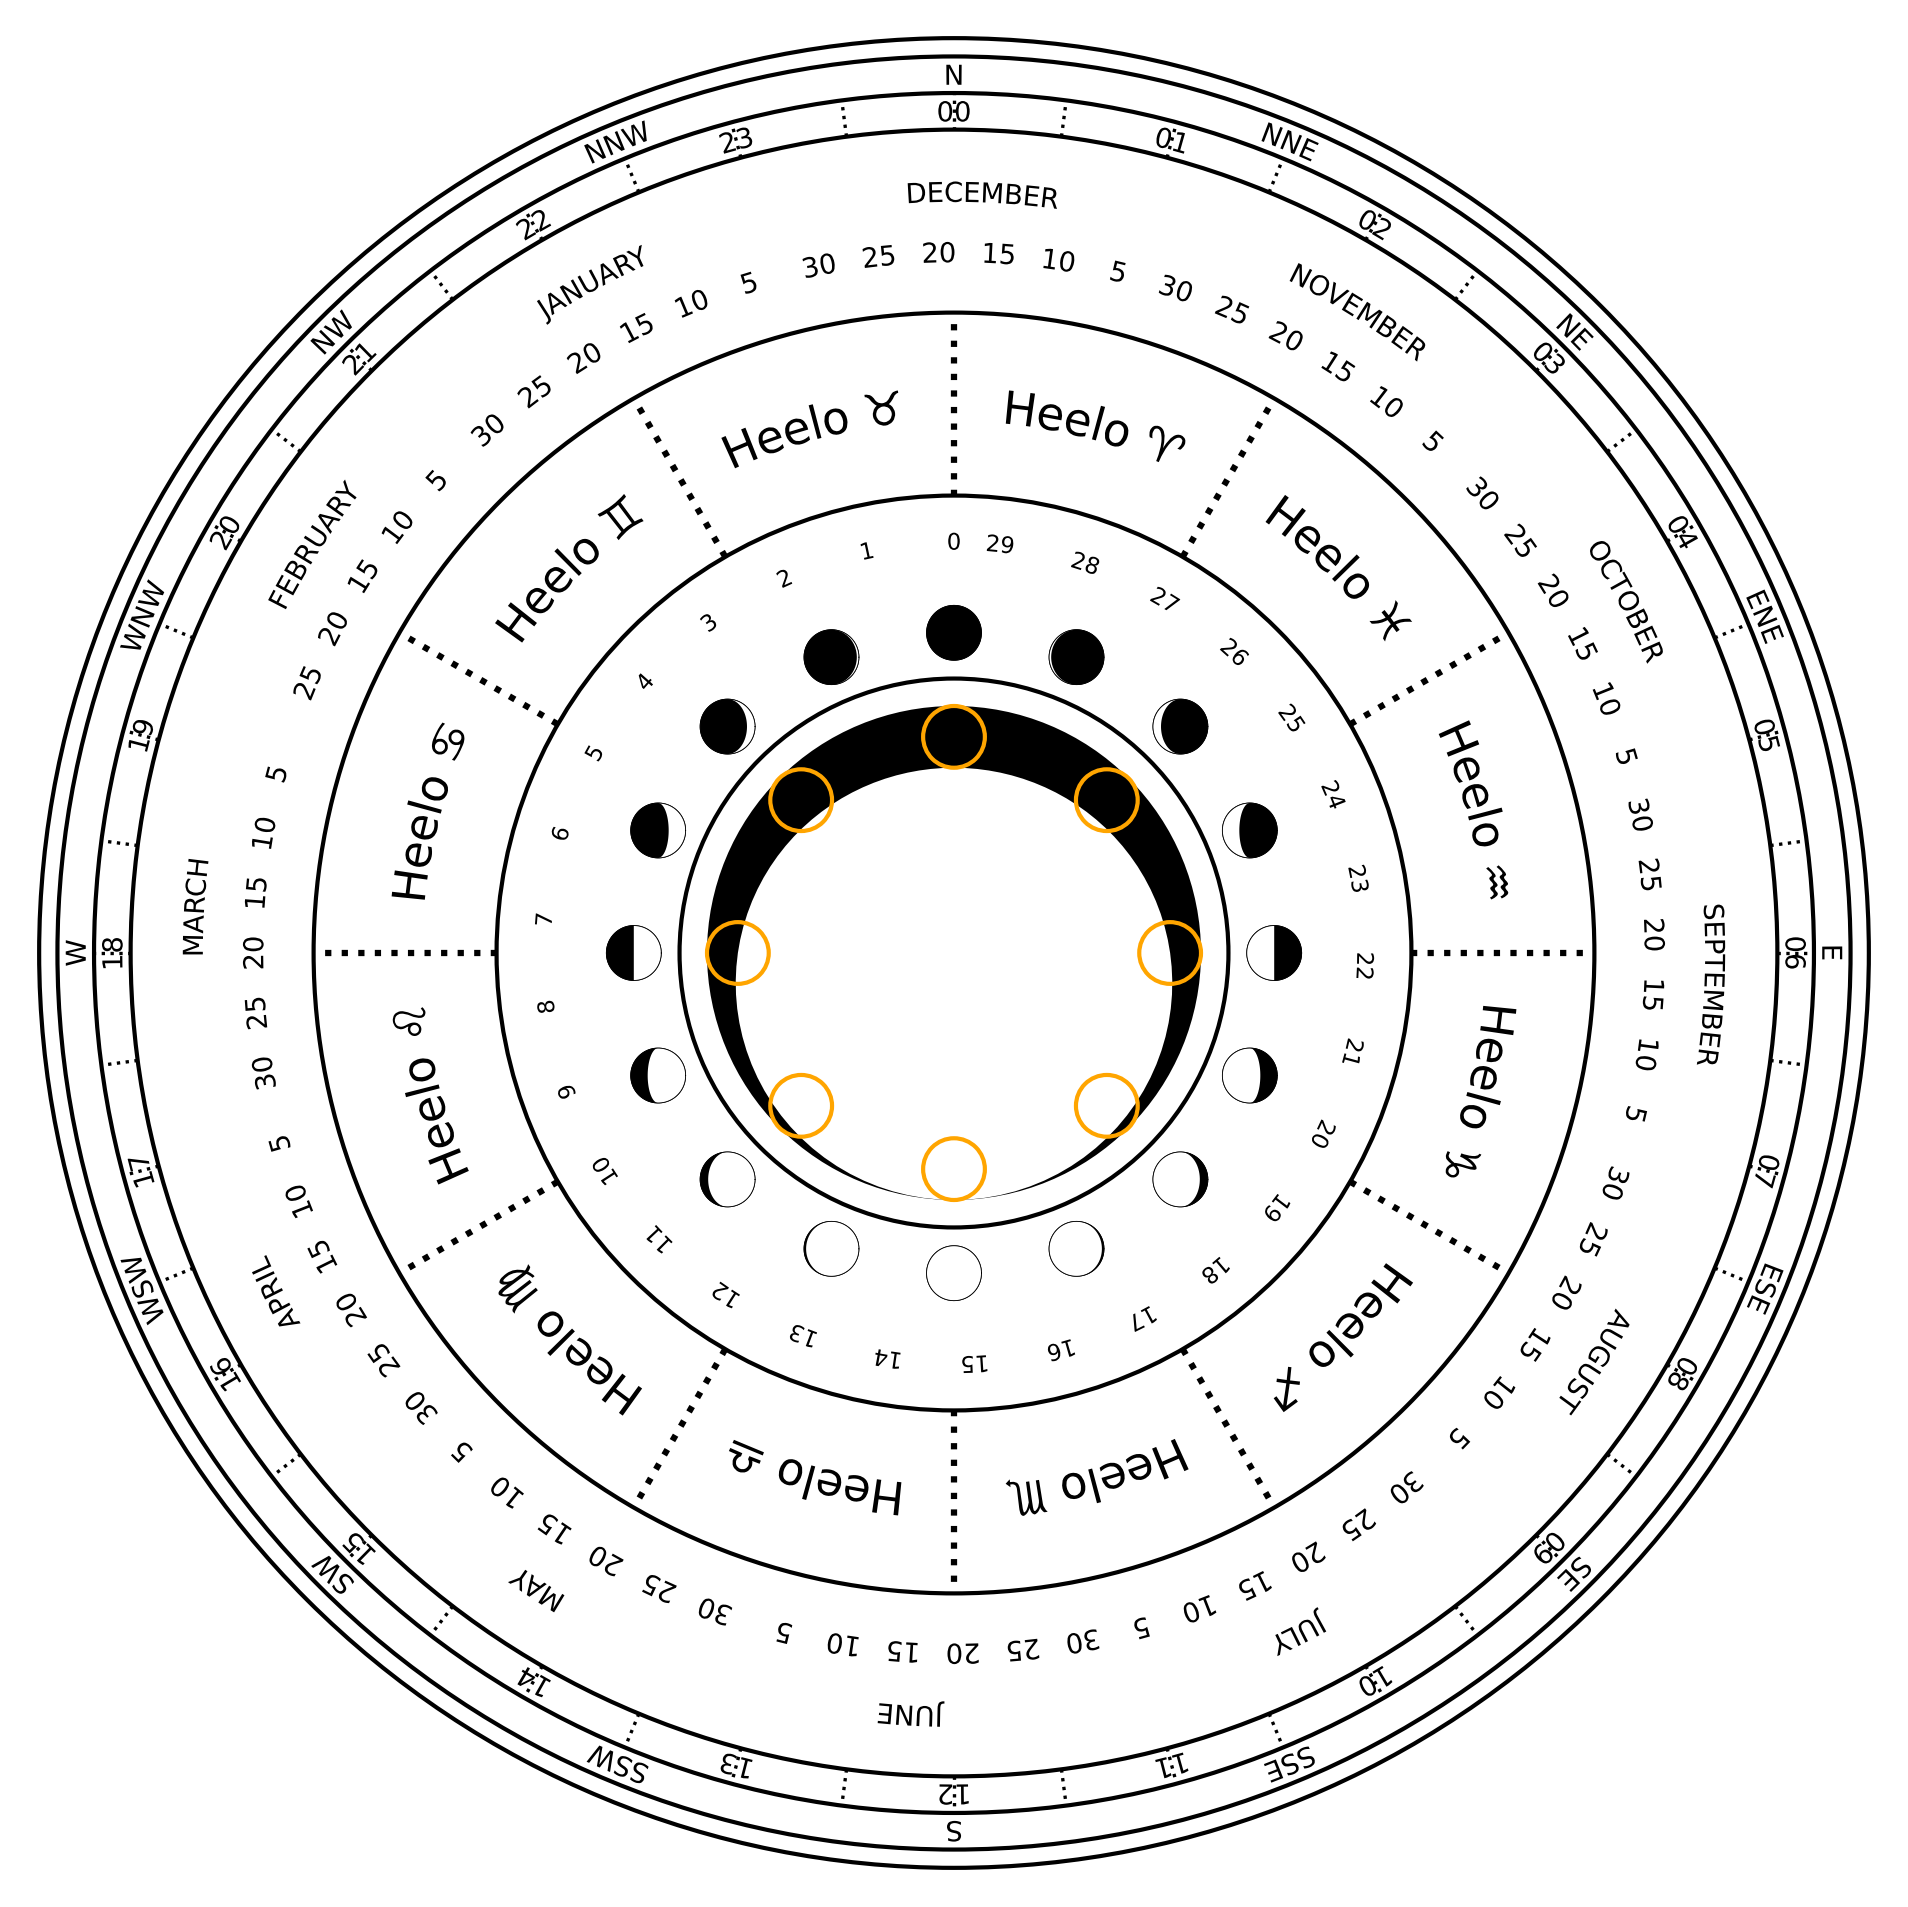

In [53]:
fig, ax = plt.subplots(figsize=(figsize, figsize), dpi=300)
fig.subplots_adjust()


r_border = figsize
r_compass = 0.98*figsize
r_time = 0.94*figsize
r_zodiac = 0.9*figsize
r_signs = 0.7*figsize
r_sun = 0.5*figsize
r_moon = 0.3*figsize

clip_circle = Circle((0,0), r_border, facecolor='none', edgecolor='k')
ax.add_patch(clip_circle)


for r in [r_compass, r_time, r_zodiac, r_signs, r_sun, r_moon]:
    ax.add_patch(Circle((0,0), r, facecolor='none', edgecolor='k'))

dir = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']

r_dir = r_time + (r_compass - r_time)*0.5

for d in range(16):
    a = np.pi/8 * d
    curved_text(ax, dir[d], r_dir, angle_offset=a, font_size=figsize*0.03)

r_hours = r_zodiac + (r_time-r_zodiac)*0.5

for h in range(24):
    a = np.pi/12 * h
    
    ax.plot((r_zodiac*np.sin(a), r_time*np.sin(a)), (r_zodiac*np.cos(a), r_time*np.cos(a)), ls=':', color='k', lw=0.8)
    curved_text(ax, f'{h:02}', r_hours, angle_offset=a, font_size=figsize*0.03)
    a = a + np.pi/24
    ax.plot((r_zodiac*np.sin(a), r_time*np.sin(a)), (r_zodiac*np.cos(a), r_time*np.cos(a)), ls=':', color='k', lw=0.8)
    

r_months = r_signs + (r_zodiac-r_signs)*0.66
r_days = r_signs + (r_zodiac-r_signs)*0.33

# Angle of the spring Equinox, which correspond to the 0 RA value, which will be down
equinox_offest = datetime(2001,3,20).timetuple().tm_yday/365

for m in range(1,13):
    days_in_month = monthrange(2001,m)[1]

    # Plot the day label
    for day in range(5,days_in_month+1,5):
        # Get the angle as a fraction of the whole year
        angle = (datetime(2001, m, day).timetuple().tm_yday/365 - equinox_offest)
        a = 2*np.pi*angle + np.pi/2
        curved_text(ax, f'{day}', r_days, angle_offset=-a, font_size=figsize*0.03)

    # Plot the month label
    angle = ((datetime(2001, m, 1).timetuple().tm_yday + days_in_month/2)/365 - equinox_offest)
    a = 2*np.pi*angle + np.pi/2
    month_name = f'{datetime(2001,m,1).strftime('%B').upper()}'
    curved_text(ax, month_name, r_months, angle_offset=-a, font_size=figsize*0.03)

zodiac_names = []
zodiac_symbols = ['\u2648', '\u2649', '\u264A', '\u264B', '\u264C', '\u264D','\u264E', '\u264F', '\u2650', '\u2651', '\u2652', '\u2653']

for i in range(12):
    a = - np.pi/6 * i
    ax.plot((r_sun*np.sin(a), r_signs*np.sin(a)), (r_sun*np.cos(a), r_signs*np.cos(a)), ls=':', color='k')
    curved_text(ax, f'Heelo {zodiac_symbols[i]}', r=(r_sun + r_signs)*0.5, angle_offset=a + np.pi/12, font_size=figsize*0.05)

sinodic_month = 29.53

r_phases = r_moon + (r_sun - r_moon)*0.75

for i in range(0,30):
    a = - 2*np.pi*i/sinodic_month
    curved_text(ax, f'{i}', r_phases, angle_offset=a, font_size=figsize*0.025)


r_cycloid = 0.9*r_moon

ax.add_patch(Circle((0,0), r_cycloid, facecolor='black'))
# Ratio between the inner radius and the moon cutout radius
ratio = 6
r_in = r_cycloid/(1 + 2/ratio)
r_mask = (r_cycloid - r_in)*0.5


# Draw the lunar cycloid
theta = np.linspace(0, 2*np.pi, 101)
vertices = np.array(((r_in - r_mask*(np.cos(theta) - 1))*np.sin(theta), (r_in - r_mask*(np.cos(theta) - 1))*np.cos(theta))).transpose()
codes = [Path.MOVETO] + [Path.LINETO]*(len(theta)-2) + [Path.CLOSEPOLY]

cycloid = PathPatch(Path(vertices, codes), facecolor='w', lw=0)
ax.add_patch(cycloid)


for i in range(8):
    x, y = (r_in + r_mask)*np.sin(i*np.pi/4), (r_in + r_mask)*np.cos(i*np.pi/4)
    ax.add_patch(Circle((x,y), r_mask, facecolor='none', edgecolor='orange'))


r_moons = r_moon + (r_sun - r_moon)*0.25
r_icons = (r_sun - r_moon)*0.15

month_length=29.53

for i in range(16):
    angle = -i*np.pi/8
    draw_moon(ax, i/16*month_length, center_xy=(r_moons*np.sin(angle), r_moons*np.cos(angle)), radius=r_icons, lw=0.2)

    
ax.set_xlim(-1.01*figsize,1.01*figsize)
ax.set_ylim(-1.01*figsize,1.01*figsize)
ax.set_aspect('equal')
ax.set_axis_off()

plt.show()

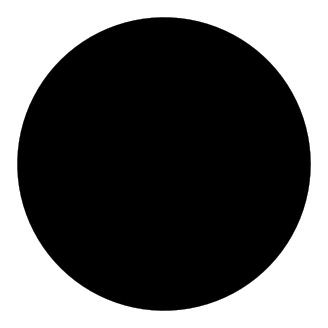

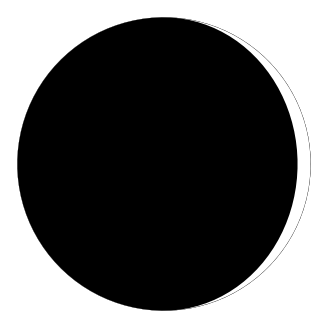

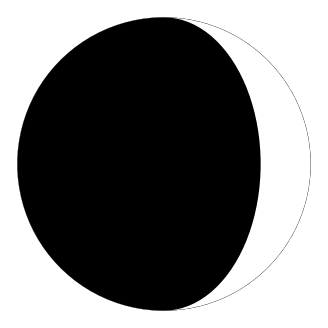

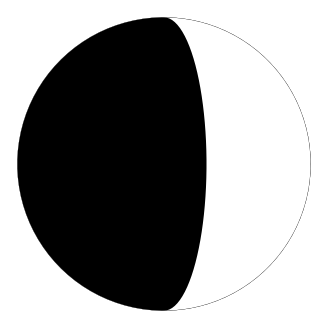

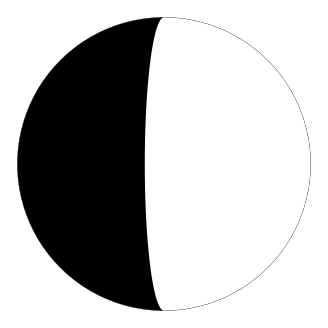

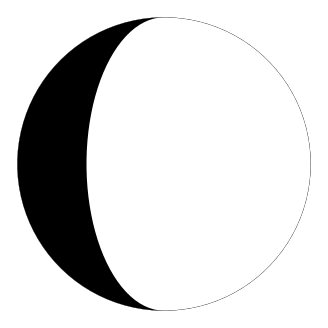

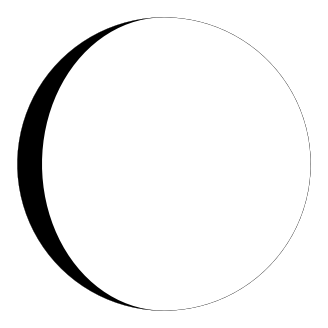

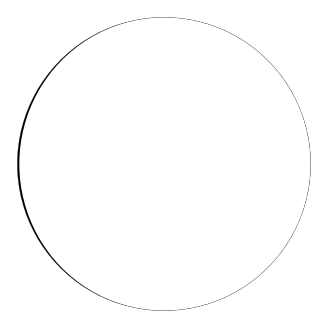

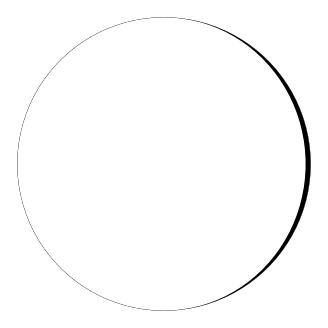

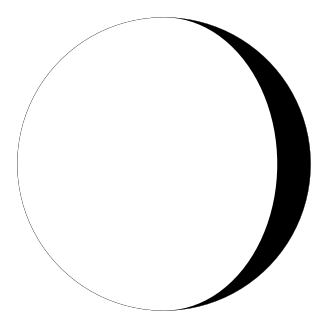

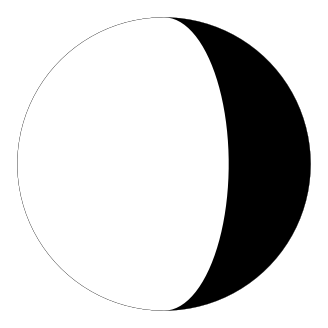

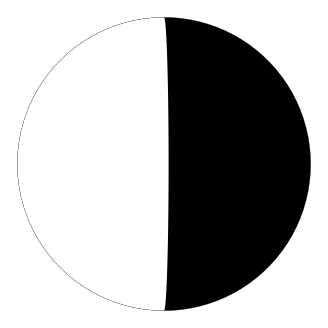

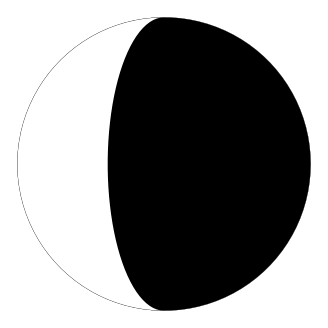

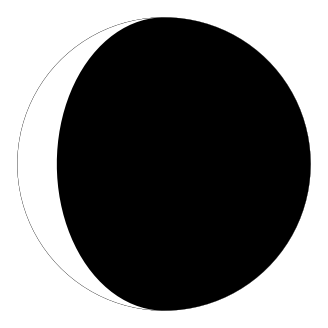

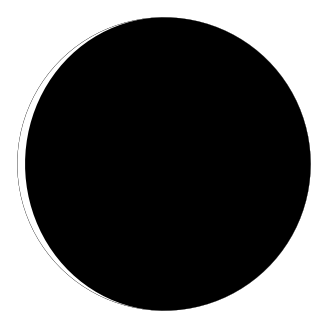

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import math

def draw_moon(ax, day, center_xy = (0,0), radius = (2), lw=0.1):
    
    (center_x, center_y) = center_xy

    month_length=29.53

    # Phase angle (Sun-Moon-Observer) from 0 (new) to to pi (full) and back
    phase_angle = 2*np.pi * (day / month_length)

    # Circle for the lunar disk
    t = np.linspace(0, 2*np.pi, 100)
    moon_x, moon_y = center_x + radius*np.cos(t), center_y + radius*np.sin(t)

    # Plot a black moon
    ax.fill(moon_x, moon_y, color="black", lw=lw)  
    ax.plot(moon_x, moon_y, color="black", lw=lw)   

    sign = 1 if phase_angle <= np.pi else -1

    # Terminator ellipse (projected shadow line)
    tt = np.linspace(-np.pi/2, np.pi/2, 50)
    x, y = center_x + radius * sign * np.cos(phase_angle) * np.cos(tt), center_y + radius * np.sin(tt)
    limb_x, limb_y = center_x + radius * sign *np.cos(tt), center_y + radius * np.sin(tt)

    # Build illuminated polygon: ellipse arc + limb arc
    # The shape is filled correctly if the points are given in counter-clockwise order
    if phase_angle <= np.pi:  # waxing (right side lit)
        poly_x = np.concatenate([x, limb_x[::-1]])
        poly_y = np.concatenate([y, limb_y[::-1]])
    else:  # waning (left side lit)

        poly_x = np.concatenate([limb_x, x[::-1]])
        poly_y = np.concatenate([limb_y, y[::-1]])

    ax.fill(poly_x, poly_y, color="white", lw=0)   # illuminated part
   



for i in range(0, 30, 2):
    fig, ax = plt.subplots(figsize=(4,4))
    ax.set_aspect("equal")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.axis("off")
    draw_moon(ax, i, radius=1)
    plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(4,4))
r_in = 0.5
r_out = 0.8
theta = np.pi/24

ax.set_aspect("equal")
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)

#draw circle with index

ax.axis("off")
plt.show()